In [12]:
import pickle 
import pandas as pd 
import os

os.chdir('..')
with open("pickles_TXO-TPA/summary_data.pkl", "rb") as f: 
    data = pickle.load(f)


In [13]:
summary_data_df = pd.DataFrame(data)


In [14]:
os.chdir("/media/sf_VirtualShared/ratcliff-group-resources/workflows/TADF_HTVS/FF_geopt_xyz_files_TXO-TPA")
xtb = pd.read_csv("txo-tpa_homo_lumo.csv")




In [15]:
import re

summary_data_df = summary_data_df.loc[:, ~summary_data_df.columns.duplicated()].copy()


if "id" not in summary_data_df.columns:
    summary_data_df = summary_data_df.reset_index().rename(columns={"index": "id"})


junk = [c for c in summary_data_df.columns
        if re.match(r"^(HOMO_xtb_eV|LUMO_xtb_eV)(_.+)?$", str(c))]
if junk:
    summary_data_df = summary_data_df.drop(columns=junk)


summary_data_df["id"] = pd.to_numeric(summary_data_df["id"], errors="coerce").astype("Int64")

xtb = xtb.reset_index(drop=True).copy()
xtb.columns = xtb.columns.astype(str).str.strip()
xtb["id"] = pd.to_numeric(xtb["id"], errors="coerce").astype("Int64")

xtb_merge = xtb[["id", "HOMO_eV", "LUMO_eV"]].copy()
xtb_merge["HOMO_xtb_eV"] = pd.to_numeric(xtb_merge["HOMO_eV"], errors="coerce")
xtb_merge["LUMO_xtb_eV"] = pd.to_numeric(xtb_merge["LUMO_eV"], errors="coerce")
xtb_merge = xtb_merge[["id", "HOMO_xtb_eV", "LUMO_xtb_eV"]]


summary_data_df = summary_data_df.merge(xtb_merge, on="id", how="left")

summary_data_df.head(50)


,id,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,...,XTB Converged?,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV
0,0,TXO-TPA,O=S1(C2=CC(C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC=C5)C...,False,False,False,57,1.0,2.376687,NaN,...,True,1.230990,True,1.057474,1.459323,0.349114,-4.86735,-3.408028,NaN,NaN
1,1,TXO-TPA_1,C#CC=CC=CN(c1ccccc1)c1ccc(-c2ccc3c(c2)S(=O)(=O...,False,False,False,57,0.65873,3.052603,NaN,...,True,0.980615,True,1.080983,1.260287,0.295308,-4.777411,-3.517124,-9.5531,-8.5725
2,2,TXO-TPA_2,CC1=C(N(c2ccccc2)c2ccc(-c3ccc4c(=O)c5ccccc5sc4...,False,False,False,60,0.439189,3.153878,NaN,...,True,1.259168,True,1.261663,1.451349,0.354732,-4.652794,-3.201445,-9.5036,-8.2444
3,3,TXO-TPA_3,O=C1c2ccccc2S(=O)(=O)c2cc(CC3=CC(N(c4ccccc4)c4...,False,False,False,60,0.677165,3.077665,NaN,...,True,0.742005,True,1.104019,0.805216,0.16853,-4.325327,-3.520111,-9.3921,-8.6501
4,4,TXO-TPA_4,O=Cc1ccccc1[SH]1(=O)C=CC=C(N(c2ccccc2)c2ccccc2...,True,False,True,57,0.431655,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,TXO-TPA_5,C=CC(C=CN(C=CC=CC)c1ccccc1)c1ccc2c(c1)S(=O)(=O...,False,False,False,59,0.442857,3.866574,NaN,...,True,0.814587,True,1.075529,1.121357,0.209033,-4.558107,-3.436751,-9.3834,-8.5688
6,6,TXO-TPA_6,O=C1c2ccccc2S(=O)(=O)c2cc(-c3ccc(-c4ccccc4-c4c...,False,False,False,55,0.725,2.172716,NaN,...,True,1.846710,True,1.007656,2.164568,0.313228,-5.67806,-3.513492,-10.4863,-8.6396
7,7,TXO-TPA_7,O=C1c2ccccc2S(=O)(=O)C2=CC(c3ccc(N(c4ccccc4)c4...,False,False,False,56,0.710744,3.305659,NaN,...,True,1.156204,True,1.398452,1.510588,0.093638,-4.718914,-3.208325,-9.6157,-8.4595
8,8,TXO-TPA_8,Cc1ccccc1P(=O)=[SH](=O)C(=O)C=CC=Cc1ccc(N(c2cc...,False,False,False,62,0.48227,3.77258,NaN,...,True,1.120027,True,2.443873,1.434059,0.237168,-4.945452,-3.511393,-9.8670,-8.7470
9,9,TXO-TPA_9,O=S1C2=CC(c3ccc(N(c4ccccc4)c4ccccc4O)cc3)=CCC(...,True,False,True,60,0.464789,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
homo_lumo_df = summary_data_df[summary_data_df["xTB HOMO-LUMO gap / eV"].notna()]
homo_lumo_df["xTB HOMO-LUMO gap / eV"].describe()

count    475.000000
mean       1.387538
std        0.544977
min        0.052835
25%        1.006830
50%        1.302407
75%        1.671240
max        3.549230
Name: xTB HOMO-LUMO gap / eV, dtype: float64

Text(0, 0.5, 'Number of molecules')

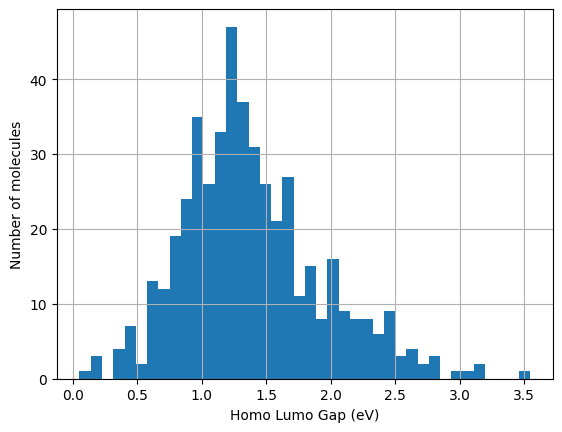

In [17]:
import matplotlib.pyplot as plt

homo_lumo_df["xTB HOMO-LUMO gap / eV"].hist(bins=40)
plt.xlabel ('Homo Lumo Gap (eV)')
plt.ylabel ('Number of molecules')

<Axes: xlabel='Number of Atoms', ylabel='xTB HOMO-LUMO gap / eV'>

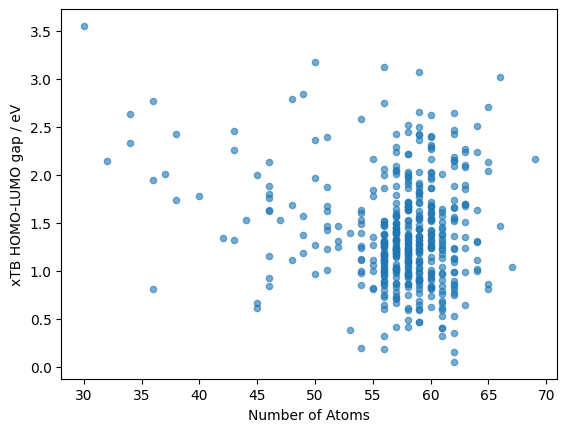

In [18]:
homo_lumo_df.plot.scatter(
    x='Number of Atoms',
    y='xTB HOMO-LUMO gap / eV',
    alpha=0.6
)

<Axes: xlabel='SAscore', ylabel='xTB HOMO-LUMO gap / eV'>

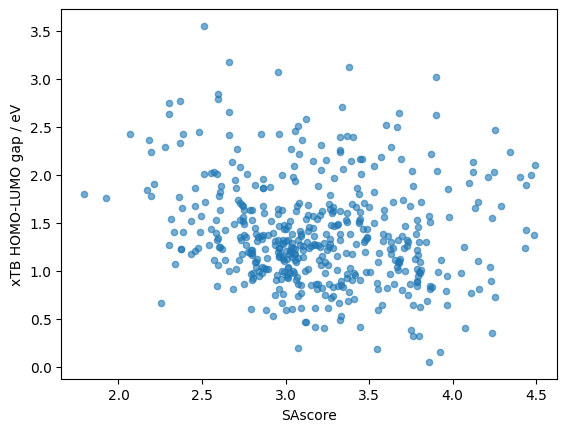

In [19]:
homo_lumo_df.plot.scatter(
    x='SAscore',
    y='xTB HOMO-LUMO gap / eV',
    alpha=0.6
)

In [20]:
cols_to_numeric = [
    "Number of Atoms",
    "SAscore",
    "Tanimoto Similarity",
    "xTB HOMO-LUMO gap / eV"
]

for col in cols_to_numeric:
    homo_lumo_df.loc[:, col] = pd.to_numeric(homo_lumo_df[col], errors="coerce")

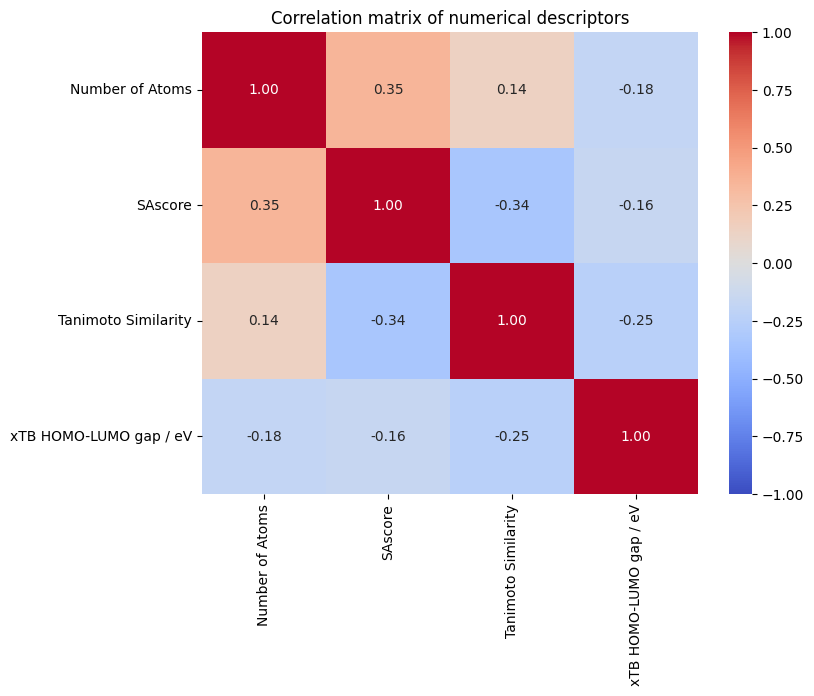

In [21]:
corr = homo_lumo_df[cols_to_numeric].corr()

import seaborn as sns 
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    cmap= "coolwarm",
    annot=True,
    fmt=".2f",
    vmin= -1,
    vmax=1
)
plt.title("Correlation matrix of numerical descriptors")
plt.show()


In [22]:
false_rows = homo_lumo_df[homo_lumo_df["HOMO-LUMO Converged?"] == False]
homo_lumo_df = homo_lumo_df.drop(false_rows.index)

In [23]:
cols = [
    "xTB HOMO-LUMO gap / eV",
    "HOMO-LUMO Gap / eV"
]

for col in cols:
    homo_lumo_df[col] = pd.to_numeric(homo_lumo_df[col], errors = "coerce")

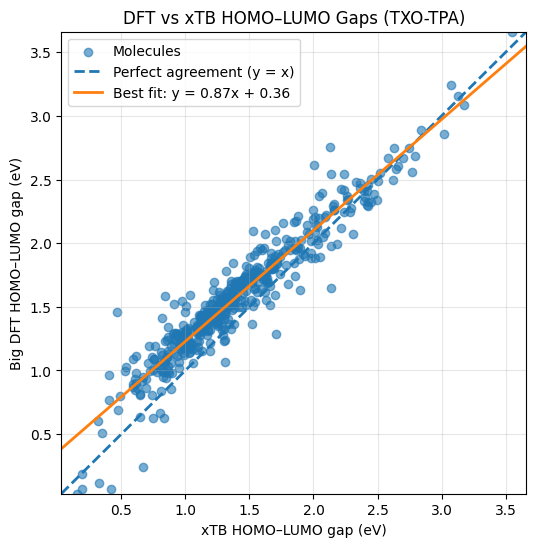

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


tmp = homo_lumo_df[
    ["xTB HOMO-LUMO gap / eV", "HOMO-LUMO Gap / eV"]
].apply(pd.to_numeric, errors="coerce").dropna()

x = tmp["xTB HOMO-LUMO gap / eV"]
y = tmp["HOMO-LUMO Gap / eV"]


plt.figure(figsize=(6, 6))

plt.scatter(x, y, alpha=0.6, label="Molecules")

min_gap = min(x.min(), y.min())
max_gap = max(x.max(), y.max())


plt.plot(
    [min_gap, max_gap],
    [min_gap, max_gap],
    "--",
    linewidth=2,
    label="Perfect agreement (y = x)"
)


m, b = np.polyfit(x, y, 1)

plt.plot(
    [min_gap, max_gap],
    [m * min_gap + b, m * max_gap + b],
    linewidth=2,
    label=f"Best fit: y = {m:.2f}x + {b:.2f}"
)

# Labels and styling
plt.xlabel("xTB HOMO–LUMO gap (eV)")
plt.ylabel("Big DFT HOMO–LUMO gap (eV)")
plt.title("DFT vs xTB HOMO–LUMO Gaps (TXO-TPA)")

plt.xlim(min_gap, max_gap)
plt.ylim(min_gap, max_gap)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [25]:
corr = homo_lumo_df["xTB HOMO-LUMO gap / eV"].corr(
    homo_lumo_df["HOMO-LUMO Gap / eV"]
)

print(corr)

0.9512618400495432


In [26]:
homo_lumo_df["Gap difference / eV"] = (
    homo_lumo_df["HOMO-LUMO Gap / eV"]
    - homo_lumo_df["xTB HOMO-LUMO gap / eV"]
)

homo_lumo_df["Gap difference / eV"].describe()



count    472.000000
mean       0.178129
std        0.167402
min       -0.490115
25%        0.100426
50%        0.190341
75%        0.272566
max        0.994201
Name: Gap difference / eV, dtype: float64

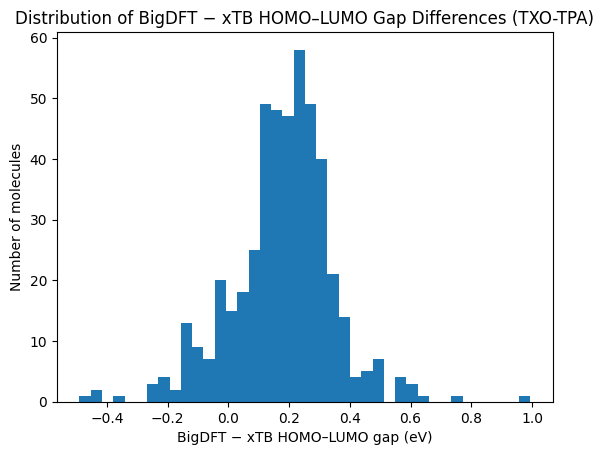

In [27]:
plt.hist(homo_lumo_df["Gap difference / eV"], bins=40)
plt.xlabel("BigDFT − xTB HOMO–LUMO gap (eV)")
plt.ylabel("Number of molecules")
plt.title("Distribution of BigDFT − xTB HOMO–LUMO Gap Differences (TXO-TPA)")
plt.show()

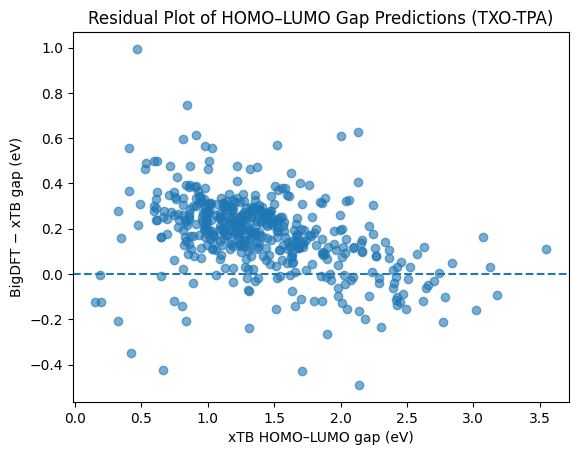

In [36]:
plt.scatter(
    homo_lumo_df["xTB HOMO-LUMO gap / eV"],
    homo_lumo_df["Gap difference / eV"],
    alpha=0.6
)
plt.axhline(0, linestyle="--")
plt.xlabel("xTB HOMO–LUMO gap (eV)")
plt.ylabel("BigDFT − xTB gap (eV)")
plt.title("Residual Plot of HOMO–LUMO Gap Predictions (TXO-TPA)")
plt.show()

In [37]:

outliers = homo_lumo_df.reindex(
    homo_lumo_df["Gap difference / eV"].abs().sort_values(ascending=False).index
)

outliers.head(5)




,id,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,...,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV,Gap difference / eV
429,429,TXO-TPA_429,O=C1c2ccccc2S(=O)(=O)c2cc(CC3=CC(N=Nc4ccccc4-c...,False,False,False,59,0.532374,3.114382,NaN,...,0.468091,True,1.495906,1.462293,0.058739,-4.972794,-3.510502,-9.1003,-8.6322,0.994201
1053,1053,TXO-TPA_1053,O=CS(=O)(=O)C=CCc1ccc(N(c2ccccc2)c2ccccc2)cc1,False,False,False,46,0.440945,2.590098,NaN,...,0.839909,True,1.316495,1.585237,0.027906,-4.706275,-3.121038,-9.6037,-8.7638,0.745328
1472,1472,TXO-TPA_1472,Cc1ccccc1-c1ccccc1C1C=CCC(C)(C=C2CC(=O)c3ccccc...,False,False,False,65,0.36,4.121996,NaN,...,2.130100,True,1.332846,2.755318,0.059643,-5.851449,-3.096131,-10.4722,-8.3421,0.625218
846,846,TXO-TPA_846,O=CP=S1c2ccccc2C(=O)c2ccc(-c3ccc(N(c4ccccc4)c4...,False,False,False,59,0.739837,3.446589,NaN,...,0.910224,True,1.311594,1.524846,0.358557,-4.858202,-3.333356,-9.5017,-8.5915,0.614622
694,694,TXO-TPA_694,O=C1c2ccccc2S(=O)(=O)c2cc(-c3ccc(B(c4ccccc4)c4...,True,False,False,57,0.75,2.769005,NaN,...,2.005648,True,1.034446,2.617056,0.584901,-6.207872,-3.590817,-10.6647,-8.6591,0.611408


In [38]:
closest = homo_lumo_df.reindex(
    homo_lumo_df["Gap difference / eV"].abs().sort_values(ascending=True).index
)

closest.head(5)

,id,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,...,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV,Gap difference / eV
953,953,TXO-TPA_953,O=Cc1ccccc1N=[SH](=O)c1cccc(C2C=CC(N(c3ccccc3)...,False,False,False,59,0.454545,4.096748,NaN,...,1.918482,True,1.508374,1.917362,0.15543,-4.551489,-2.634127,-9.3939,-7.4754,-0.001119
1522,1522,TXO-TPA_1522,C=C1c2ccccc2S(=O)(=O)c2cc(-c3ccc(N(c4ccccc4)c4...,False,False,False,59,0.891892,2.569117,NaN,...,2.028895,True,0.809288,2.025174,0.336841,-4.692714,-2.667541,-9.6014,-7.5725,-0.003722
1557,1557,TXO-TPA_1557,c1ccc(N(c2ccccc2)c2ccc(-c3ccc4c(c3)Sc3ccccc3C4...,True,False,False,56,0.658537,2.303774,NaN,...,2.744940,True,0.709206,2.748760,0.616519,-4.554089,-1.805329,-9.4713,-6.7263,0.003821
142,142,TXO-TPA_142,O=Cc1ccccc1S(=O)(=O)C1=CC(C=CC=C2C=Cc3ccccc3N2...,True,False,False,56,0.301887,3.549302,NaN,...,0.189056,True,1.416354,0.185084,0.876448,-4.273219,-4.088135,-9.0765,-8.8874,-0.003971
350,350,TXO-TPA_350,O=C1C2=C(CN=C=C2)S(=O)(=O)c2cc(-c3ccc(N(c4cccc...,False,False,False,56,0.721311,3.213432,NaN,...,1.058460,True,1.236247,1.054347,0.265472,-4.944936,-3.890589,-9.8867,-8.8283,-0.004114


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


tmp = homo_lumo_df[["HOMO_xtb_eV", "HOMO / eV"]].copy()
tmp["HOMO_xtb_eV"] = pd.to_numeric(tmp["HOMO_xtb_eV"], errors="coerce")
tmp["HOMO / eV"]   = pd.to_numeric(tmp["HOMO / eV"], errors="coerce")
tmp = tmp.dropna()

x = tmp["HOMO_xtb_eV"].to_numpy()
y = tmp["HOMO / eV"].to_numpy()

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6)

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())




m, b = np.polyfit(x, y, 1)
plt.plot([min_val, max_val], [m*min_val + b, m*max_val + b])

plt.xlabel("xTB HOMO (eV)")
plt.ylabel("DFT HOMO (eV)")
plt.title(f"HOMO comparison: y = {m:.3f}x + {b:.3f}")
plt.show()

print("HOMO slope:", m)
print("HOMO intercept:", b)
print("Points used:", len(tmp))


In [ ]:
tmp = homo_lumo_df[["LUMO_xtb_eV", "LUMO / eV"]].copy()
tmp["LUMO_xtb_eV"] = pd.to_numeric(tmp["LUMO_xtb_eV"], errors="coerce")
tmp["LUMO / eV"]   = pd.to_numeric(tmp["LUMO / eV"], errors="coerce")
tmp = tmp.dropna()

x = tmp["LUMO_xtb_eV"].to_numpy()
y = tmp["LUMO / eV"].to_numpy()

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6)

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())


m, b = np.polyfit(x, y, 1)
plt.plot([min_val, max_val], [m*min_val + b, m*max_val + b])

plt.xlabel("xTB LUMO (eV)")
plt.ylabel("DFT LUMO (eV)")
plt.title(f"LUMO comparison: y = {m:.3f}x + {b:.3f}")
plt.show()

print("LUMO slope:", m)
print("LUMO intercept:", b)
print("Points used:", len(tmp))

In [28]:


mismatch_df = homo_lumo_df.copy()

for c in ["HOMO_xtb_eV", "LUMO_xtb_eV", "HOMO / eV", "LUMO / eV"]:
    mismatch_df[c] = pd.to_numeric(mismatch_df[c], errors="coerce")


mismatch_df["delta_HOMO_xtb_minus_dft_eV"] = (
    mismatch_df["HOMO_xtb_eV"] - mismatch_df["HOMO / eV"]
)

mismatch_df["delta_LUMO_xtb_minus_dft_eV"] = (
    mismatch_df["LUMO_xtb_eV"] - mismatch_df["LUMO / eV"]
)


mismatch_df["abs_delta_HOMO_eV"] = mismatch_df["delta_HOMO_xtb_minus_dft_eV"].abs()
mismatch_df["abs_delta_LUMO_eV"] = mismatch_df["delta_LUMO_xtb_minus_dft_eV"].abs()

i_h = mismatch_df["abs_delta_HOMO_eV"].idxmax()
i_l = mismatch_df["abs_delta_LUMO_eV"].idxmax()

biggest_homo = mismatch_df.loc[
    i_h,
    ["id", "HOMO_xtb_eV", "HOMO / eV",
     "delta_HOMO_xtb_minus_dft_eV", "abs_delta_HOMO_eV"]
]

biggest_lumo = mismatch_df.loc[
    i_l,
    ["id", "LUMO_xtb_eV", "LUMO / eV",
     "delta_LUMO_xtb_minus_dft_eV", "abs_delta_LUMO_eV"]
]

print("Biggest HOMO xTB–DFT mismatch:")
print(biggest_homo)

print("\nBiggest LUMO xTB–DFT mismatch:")
print(biggest_lumo)

Biggest HOMO xTB–DFT mismatch:
id                                  248
HOMO_xtb_eV                     -9.8738
HOMO / eV                     -4.768447
delta_HOMO_xtb_minus_dft_eV   -5.105353
abs_delta_HOMO_eV              5.105353
Name: 248, dtype: object

Biggest LUMO xTB–DFT mismatch:
id                                 1053
LUMO_xtb_eV                     -8.7638
LUMO / eV                     -3.121038
delta_LUMO_xtb_minus_dft_eV   -5.642762
abs_delta_LUMO_eV              5.642762
Name: 1053, dtype: object


In [29]:
N = 10  

top_homo = mismatch_df.sort_values(
    "abs_delta_HOMO_eV", ascending=False
).head(N)[
    ["id", "HOMO_xtb_eV", "HOMO / eV",
     "delta_HOMO_xtb_minus_dft_eV", "abs_delta_HOMO_eV"]
]

top_lumo = mismatch_df.sort_values(
    "abs_delta_LUMO_eV", ascending=False
).head(N)[
    ["id", "LUMO_xtb_eV", "LUMO / eV",
     "delta_LUMO_xtb_minus_dft_eV", "abs_delta_LUMO_eV"]
]

print("Top HOMO mismatches:")
display(top_homo)

print("\nTop LUMO mismatches:")
display(top_lumo)

Top HOMO mismatches:


,id,HOMO_xtb_eV,HOMO / eV,delta_HOMO_xtb_minus_dft_eV,abs_delta_HOMO_eV
248,248,-9.8738,-4.768447,-5.105353,5.105353
302,302,-9.6890,-4.614965,-5.074035,5.074035
895,895,-10.6548,-5.585495,-5.069305,5.069305
3,3,-9.3921,-4.325327,-5.066773,5.066773
1752,1752,-9.0684,-4.044927,-5.023473,5.023473
885,885,-9.2968,-4.290567,-5.006233,5.006233
1509,1509,-9.4375,-4.442123,-4.995377,4.995377
1176,1176,-9.7338,-4.739586,-4.994214,4.994214
834,834,-9.6678,-4.674802,-4.992998,4.992998
976,976,-10.3241,-5.331164,-4.992936,4.992936



Top LUMO mismatches:


,id,LUMO_xtb_eV,LUMO / eV,delta_LUMO_xtb_minus_dft_eV,abs_delta_LUMO_eV
1053,1053,-8.7638,-3.121038,-5.642762,5.642762
836,836,-8.0997,-2.666410,-5.433290,5.433290
349,349,-8.4681,-3.053788,-5.414312,5.414312
1383,1383,-7.9844,-2.670732,-5.313668,5.313668
1695,1695,-7.7402,-2.432468,-5.307732,5.307732
495,495,-8.1971,-2.915147,-5.281953,5.281953
1067,1067,-8.3965,-3.125492,-5.271008,5.271008
846,846,-8.5915,-3.333356,-5.258144,5.258144
1526,1526,-8.2557,-3.004041,-5.251659,5.251659
7,7,-8.4595,-3.208325,-5.251175,5.251175


In [ ]:

i_h_close = mismatch_df["abs_delta_HOMO_eV"].idxmin()
closest_homo = mismatch_df.loc[
    i_h_close,
    ["id", "HOMO_xtb_eV", "HOMO / eV",
     "delta_HOMO_xtb_minus_dft_eV", "abs_delta_HOMO_eV"]
]


i_l_close = mismatch_df["abs_delta_LUMO_eV"].idxmin()
closest_lumo = mismatch_df.loc[
    i_l_close,
    ["id", "LUMO_xtb_eV", "LUMO / eV",
     "delta_LUMO_xtb_minus_dft_eV", "abs_delta_LUMO_eV"]
]

print("Closest HOMO xTB–DFT match:")
print(closest_homo)

print("\nClosest LUMO xTB–DFT match:")
print(closest_lumo)

In [ ]:
N = 10  

closest_homo_N = mismatch_df.sort_values(
    "abs_delta_HOMO_eV", ascending=True
).head(N)[
    ["id", "HOMO_xtb_eV", "HOMO / eV",
     "delta_HOMO_xtb_minus_dft_eV", "abs_delta_HOMO_eV"]
]

closest_lumo_N = mismatch_df.sort_values(
    "abs_delta_LUMO_eV", ascending=True
).head(N)[
    ["id", "LUMO_xtb_eV", "LUMO / eV",
     "delta_LUMO_xtb_minus_dft_eV", "abs_delta_LUMO_eV"]
]

print("Top closest HOMO matches:")
display(closest_homo_N)

print("\nTop closest LUMO matches:")
display(closest_lumo_N)